# Initializing the Notebook


In [2]:
pip install implicit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 8.9 MB/s eta 0:00:00


In [3]:
from implicit.datasets.lastfm import get_lastfm

artists, users, artist_user_plays = get_lastfm()

/usr/local/lib/python3.10/dist-packages/implicit/gpu/__init__.py:13: UserWarning: CUDA extension is built, but disabling GPU support because of 'Cuda Error: CUDA driver version is insufficient for CUDA runtime version (/project/./implicit/gpu/utils.h:71)'
  warnings.warn(


0.00B [00:00, ?B/s]

In [9]:
print(len(artists))

292385


In [7]:
print(users[:10])

['00000c289a1829a808ac09c00daf10bc3c4e223b'
 '00001411dc427966b17297bf4d69e7e193135d89'
 '00004d2ac9316e22dc007ab2243d6fcb239e707d'
 '000063d3fe1cf2ba248b9e3c3f0334845a27a6bf'
 '00007a47085b9aab8af55f52ec8846ac479ac4fe'
 '0000c176103e538d5c9828e695fed4f7ae42dd01'
 '0000ee7dd906373efa37f4e1185bfe1e3f8695ae'
 '0000ef373bbd0d89ce796abae961f2705e8c1faf'
 '0000f687d4fe9c1ed49620fbc5ed5b0d7798ea20'
 '0001399387da41d557219578fb08b12afa25ab67']


In [8]:
print(artist_user_plays)

  (0, 73470)	32.0
  (0, 97856)	24.0
  (0, 235382)	1339.0
  (0, 266072)	211.0
  (1, 171865)	23.0
  (2, 180892)	70.0
  (3, 285031)	23.0
  (4, 15103)	9.0
  (5, 81700)	16.0
  (6, 284057)	56.0
  (7, 335320)	24.0
  (8, 182831)	113.0
  (9, 12461)	3.0
  (10, 78717)	2.0
  (10, 149431)	2.0
  (10, 220512)	2.0
  (10, 261830)	2.0
  (10, 280610)	2.0
  (10, 297146)	2.0
  (11, 296825)	118.0
  (12, 332435)	202.0
  (13, 41075)	30.0
  (14, 298571)	138.0
  (15, 295693)	219.0
  (16, 185703)	35.0
  :	:
  (292364, 4775)	5.0
  (292365, 147943)	1329.0
  (292366, 95230)	157.0
  (292367, 56086)	5.0
  (292367, 137277)	70.0
  (292367, 287297)	87.0
  (292368, 294859)	68.0
  (292369, 308202)	125.0
  (292370, 42122)	315.0
  (292370, 263053)	729.0
  (292370, 301225)	7.0
  (292371, 229732)	3.0
  (292372, 355627)	384.0
  (292373, 337693)	486.0
  (292374, 212855)	48.0
  (292375, 231253)	127.0
  (292376, 147738)	7.0
  (292377, 220443)	125.0
  (292378, 219957)	1.0
  (292379, 14949)	66.0
  (292380, 218794)	25.0
  (292381, 2

In [ ]:
# import the necessary libraries

import pandas as pd
import numpy as np
import os
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# mount the google drive

from pandas.io.parsers.readers import csv
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# check current working directory

os.getcwd()

'/content'

In [ ]:
# navigate to the file

os.chdir("/content/drive/MyDrive/abw_project_personalization")
os.getcwd()

'/content/drive/MyDrive/abw_project_personalization'

In [ ]:
#load the data

os.listdir()

['user_profiles.csv',
 'Archive Data',
 'Result',
 'user_profiles.gsheet',
 'transformed_card_data.xlsx',
 'ABW Project proposal template.docx',
 'Meeting Note: Personalized Recommendation.gdoc',
 'user_trend.ipynb']

In [ ]:
# read the file

df = pd.read_csv('user_profiles.csv')

In [ ]:
# verify the data loaded correctly

df.head()

,user_id,platform,name,phonenumber,email_address,region,gender,age,ethnicity,township,...,Total average active days per month,Total amount of money spent,Least active duration per session,Most active duration per session,Average usage duration per session,Average number of session per day,Average usage duration per day,Total Courses Taken in life time,Total Certificates Count in life time,Activity Point
0,60430,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,...,0,0,NaN,NaN,NaN,NaN,NaN,0,0,0
1,60431,Messenger,minn khine zaw,+95 9 689 557899,bone htet 7394@gmail. com,rakhine,male,twentysix_thirtytwo,NaN,NaN,...,2,0,00:00:00,00:14:59,00:03:53,1.0,00:04:32,4,0,9
2,60432,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,...,0,0,NaN,NaN,NaN,NaN,NaN,0,0,0
3,60433,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,...,0,0,NaN,NaN,NaN,NaN,NaN,0,0,0
4,60434,Messenger,Su Myat Myat Oo,NaN,NaN,NaN,female,NaN,NaN,NaN,...,1,0,00:00:00,00:04:58,00:01:23,4.0,00:05:32,1,0,2


## Data Exploration

In [ ]:
# get basic information about the dataset

df.describe ()

,user_id,Recency Score,Frequency Score,Monetary Score,Numbers of days since last visit,Numbers of days since last purchase,Total average active days per week,Total average active days per month,Total amount of money spent,Average number of session per day,Total Courses Taken in life time,Total Certificates Count in life time,Activity Point
count,7.776000e+04,77760.000000,77760.000000,77760.000000,22042.000000,658.000000,77760.000000,77760.000000,77760.000000,22042.000000,77760.000000,77760.000000,77760.000000
mean,2.392205e+05,1.199576,0.303794,0.014738,254.122902,240.437690,0.392914,0.516204,241.031379,1.507486,0.862101,0.032189,2.569843
std,3.484416e+05,1.928151,0.511528,0.141145,143.508046,126.085026,0.707859,1.045399,4938.184045,0.793938,1.826459,0.223045,9.717396
min,6.043000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,7.988375e+04,0.000000,0.000000,0.000000,130.000000,118.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,9.932350e+04,0.000000,0.000000,0.000000,257.000000,277.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,1.187632e+05,4.000000,1.000000,0.000000,376.000000,350.000000,1.000000,1.000000,0.000000,2.000000,1.000000,0.000000,0.000000
max,1.509163e+06,5.000000,5.000000,4.000000,535.000000,427.000000,6.000000,14.000000,770700.000000,17.000000,55.000000,8.000000,397.000000


In [ ]:
#check missing values

df.isnull().sum()

user_id                                      0
platform                                 55718
name                                     55771
phonenumber                              52720
email_address                            70044
region                                   54031
gender                                    8621
age                                      59381
ethnicity                                77072
township                                 69692
employment                               69186
profession                               13827
education                                74909
university                               70505
device                                   76105
Recency Score                                0
Frequency Score                              0
Monetary Score                               0
Numbers of days since last visit         55718
Numbers of days since last purchase      77102
Total average active days per week           0
Total average

## Data Selection


In [ ]:
selected_features = df[['Recency Score', 'Frequency Score', 'Monetary Score', 'Activity Point', 'Total Courses Taken in life time']]


## Standardize the Data

In [ ]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(selected_features)


# Clustering to discover user personas


Finding user persona based on user interested skills-scores.

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

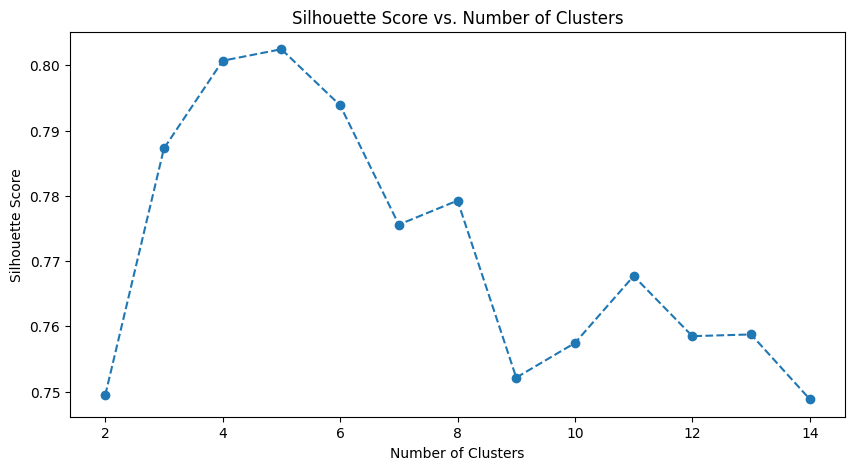

In [ ]:
scores = []
range_values = range(2, 15)
for i in range_values:
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data_scaled)
    scores.append(silhouette_score(data_scaled, kmeans.labels_))

# Plot the results
plt.figure(figsize=(10,5))
plt.plot(range_values, scores, marker='o', linestyle='--')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()


In [ ]:
# Run KMeans Clustering

optimal_clusters = 14
kmeans = KMeans(n_clusters=optimal_clusters)
kmeans.fit(data_scaled)
df['Cluster'] = kmeans.labels_

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


## Analyze clusters to define user personas

In [ ]:
df.groupby('Cluster').mean()

<ipython-input-37-9780075f7ef4>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df.groupby('Cluster').mean()


,user_id,Recency Score,Frequency Score,Monetary Score,Numbers of days since last visit,Numbers of days since last purchase,Total average active days per week,Total average active days per month,Total amount of money spent,Average number of session per day,Total Courses Taken in life time,Total Certificates Count in life time,Activity Point
Cluster,,,,,,,,,,,,,
0,111598.735497,0.000000,0.000101,0.000000,1.250000,NaN,0.000101,0.000101,0.000000,1.000000,0.000000,0.000000,0.002244
1,606626.026242,4.183542,1.000000,0.000000,295.746942,NaN,1.132064,1.237421,0.000000,1.316225,0.510373,0.004412,1.818703
2,227309.729730,4.171171,1.090090,1.090090,64.369369,246.910714,2.081081,4.756757,14509.909910,1.981982,14.243243,1.378378,112.963964
3,309267.608187,4.830409,1.005848,0.000000,58.520468,NaN,1.877193,3.742690,0.000000,1.918129,17.824561,1.432749,81.935673
4,583128.302682,3.634100,1.162835,1.000000,227.883142,228.627778,1.873563,3.444444,11622.413793,1.796935,2.285441,0.160920,17.427203
5,501095.202173,4.515389,1.030779,0.000000,149.715751,NaN,1.711527,2.852142,0.000000,1.796620,5.179843,0.423054,25.372963
6,78069.660979,0.000000,0.000638,0.000000,0.750000,NaN,0.000797,0.001276,0.000000,1.500000,2.344762,0.000000,0.028385
7,483827.694030,3.216418,1.201493,2.074627,203.305970,263.151515,1.865672,2.858209,46239.552239,1.850746,3.059701,0.141791,16.358209
8,703665.753040,4.188962,2.260056,0.000000,263.493920,NaN,3.067353,3.517306,0.000000,2.367633,1.484565,0.105706,9.772685


In [ ]:
print(df.head())

NameError: ignored

In [ ]:
df.to_csv('user_persona.csv', index=False)


# Feature Selection

Finding the relevant feature selection and representation of features.  

Simple question -- what to recommend by how?

# Recommendation Model

## Building Model

## Evaluating Model